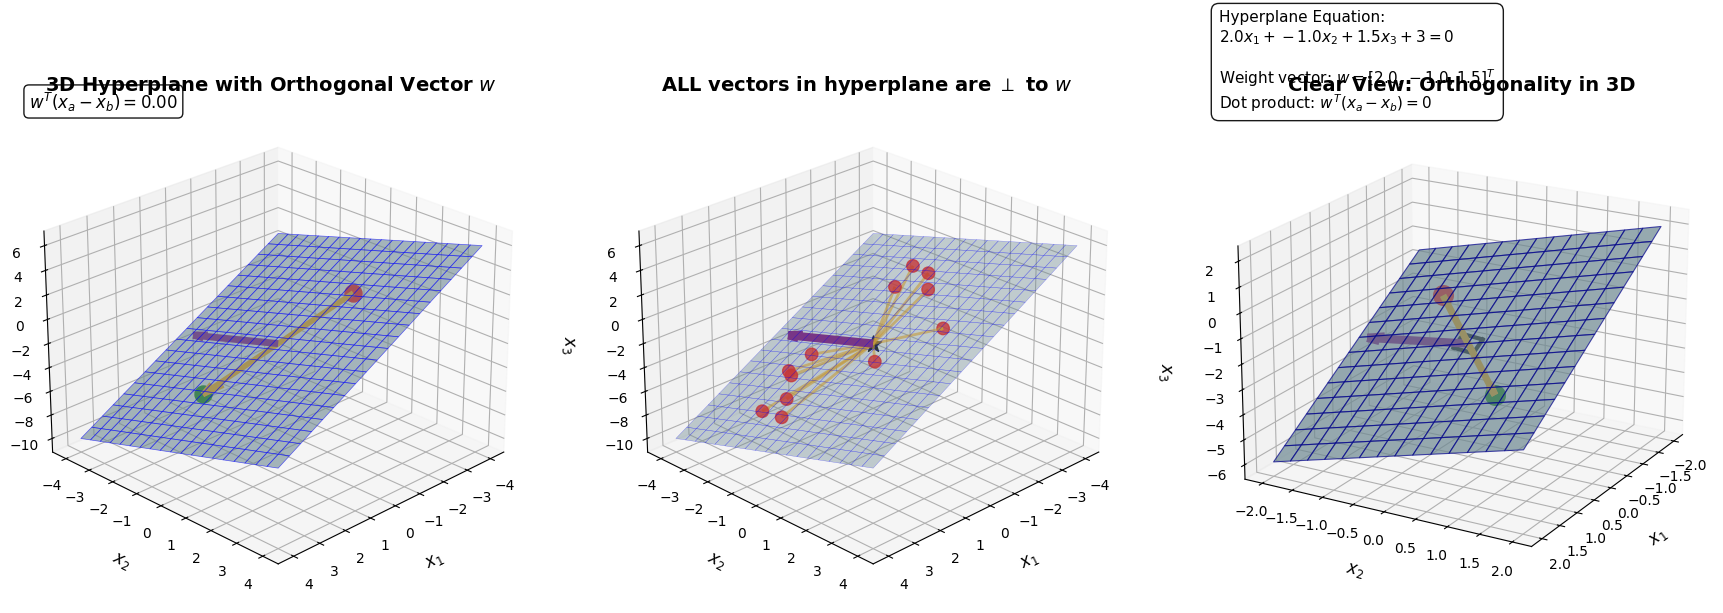

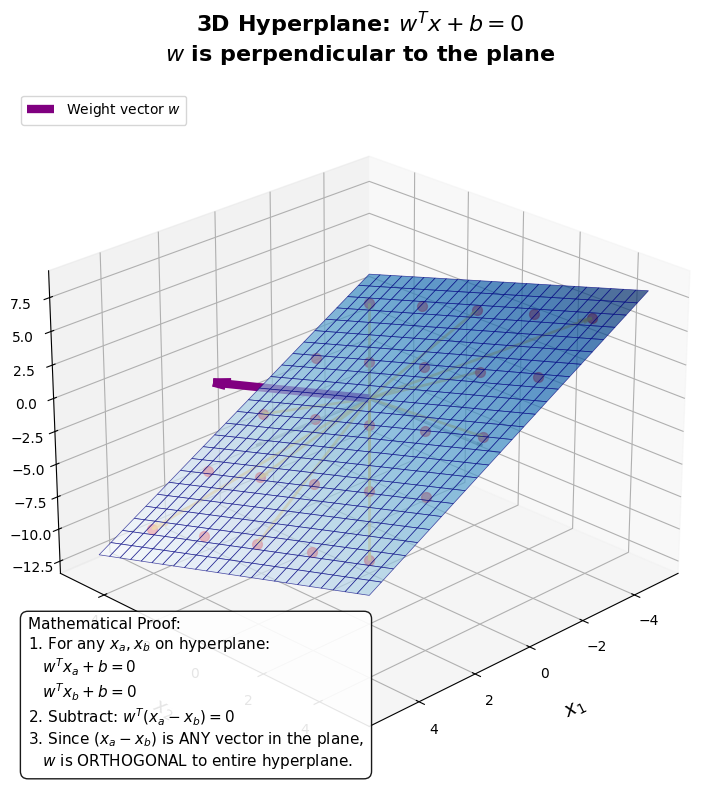

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create figure with multiple views
fig = plt.figure(figsize=(18, 6))

# =============================================
# Plot 1: 3D Hyperplane with vectors
# =============================================
ax1 = fig.add_subplot(131, projection='3d')

# Define hyperplane parameters
w = np.array([2, -1, 1.5])  # weight vector
b = 3  # bias term

# Create grid for the hyperplane
x = np.linspace(-4, 4, 20)
y = np.linspace(-4, 4, 20)
X, Y = np.meshgrid(x, y)
# Hyperplane equation: w1*x + w2*y + w3*z + b = 0 => z = -(w1*x + w2*y + b)/w3
Z = -(w[0] * X + w[1] * Y + b) / w[2]

# Plot the hyperplane surface
surface = ax1.plot_surface(X, Y, Z, alpha=0.6, color='lightblue',
                           edgecolor='blue', linewidth=0.5, label='Hyperplane: $w^T x + b = 0$')

# Create two points ON the hyperplane
# First point: choose x=-2, y=1, solve for z
x_a = np.array([-2, 1, -(w[0]*(-2) + w[1]*1 + b)/w[2]])
# Second point: choose x=2, y=-1, solve for z
x_b = np.array([2, -1, -(w[0]*2 + w[1]*(-1) + b)/w[2]])

# Plot the points
ax1.scatter(x_a[0], x_a[1], x_a[2], color='red', s=150, depthshade=True, label='$x_a$')
ax1.scatter(x_b[0], x_b[1], x_b[2], color='green', s=150, depthshade=True, label='$x_b$')

# Draw vector connecting x_a to x_b (lies IN the hyperplane)
connection_vector = x_b - x_a
ax1.quiver(x_a[0], x_a[1], x_a[2],
           connection_vector[0], connection_vector[1], connection_vector[2],
           color='orange', linewidth=4, arrow_length_ratio=0.1,
           label='$x_a - x_b$')

# Draw the weight vector w (orthogonal to hyperplane)
# Start from midpoint for better visualization
midpoint = (x_a + x_b) / 2
w_scaled = w / np.linalg.norm(w) * 3  # Scale for visibility
ax1.quiver(midpoint[0], midpoint[1], midpoint[2],
           w_scaled[0], w_scaled[1], w_scaled[2],
           color='purple', linewidth=5, arrow_length_ratio=0.15,
           label='$w$')

# Set labels and title
ax1.set_xlabel('$x_1$', fontsize=12, labelpad=10)
ax1.set_ylabel('$x_2$', fontsize=12, labelpad=10)
ax1.set_zlabel('$x_3$', fontsize=12, labelpad=10)
ax1.set_title('3D Hyperplane with Orthogonal Vector $w$', fontsize=14, fontweight='bold')

# Set viewing angle for better visibility
ax1.view_init(elev=25, azim=45)

# Add text showing orthogonality
dot_product = np.dot(w, connection_vector)
ax1.text2D(0.02, 0.98, f'$w^T(x_a - x_b) = {dot_product:.2f}$',
           transform=ax1.transAxes, fontsize=12, fontweight='bold',
           bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9))

# =============================================
# Plot 2: Multiple points showing orthogonality
# =============================================
ax2 = fig.add_subplot(132, projection='3d')

# Plot the same hyperplane
ax2.plot_surface(X, Y, Z, alpha=0.4, color='lightblue', edgecolor='blue', linewidth=0.3)

# Generate multiple random points on the hyperplane
np.random.seed(42)
num_points = 12
x1_random = np.random.uniform(-3, 3, num_points)
x2_random = np.random.uniform(-3, 3, num_points)
x3_random = -(w[0] * x1_random + w[1] * x2_random + b) / w[2]

# Plot all points
ax2.scatter(x1_random, x2_random, x3_random, color='red', s=80, alpha=0.8, depthshade=True)

# Choose a reference point near center
ref_point = np.array([0, 0, -b/w[2]])  # x1=0, x2=0
ax2.scatter(ref_point[0], ref_point[1], ref_point[2], color='black', s=150, marker='*', depthshade=True)

# Draw vectors from reference point to each point
for i in range(num_points):
    point = np.array([x1_random[i], x2_random[i], x3_random[i]])
    vec = point - ref_point
    ax2.quiver(ref_point[0], ref_point[1], ref_point[2],
               vec[0], vec[1], vec[2],
               color='orange', linewidth=2, alpha=0.6, arrow_length_ratio=0.05)

    # Check orthogonality
    dot = np.dot(w, vec)
    if abs(dot) > 1e-10:  # Should be very close to 0
        print(f"Warning: Dot product not zero: {dot}")

# Draw the weight vector w from reference point
ax2.quiver(ref_point[0], ref_point[1], ref_point[2],
           w_scaled[0], w_scaled[1], w_scaled[2],
           color='purple', linewidth=6, arrow_length_ratio=0.15, label='$w$')

ax2.set_xlabel('$x_1$', fontsize=12, labelpad=10)
ax2.set_ylabel('$x_2$', fontsize=12, labelpad=10)
ax2.set_zlabel('$x_3$', fontsize=12, labelpad=10)
ax2.set_title('ALL vectors in hyperplane are $\\perp$ to $w$', fontsize=14, fontweight='bold')
ax2.view_init(elev=25, azim=45)

# =============================================
# Plot 3: Clear view showing perpendicularity
# =============================================
ax3 = fig.add_subplot(133, projection='3d')

# Create a simpler, smaller plane for clarity
x_simple = np.linspace(-2, 2, 15)
y_simple = np.linspace(-2, 2, 15)
X_simple, Y_simple = np.meshgrid(x_simple, y_simple)
Z_simple = -(w[0] * X_simple + w[1] * Y_simple + b) / w[2]

# Plot the hyperplane
ax3.plot_surface(X_simple, Y_simple, Z_simple, alpha=0.7, color='lightblue',
                 edgecolor='darkblue', linewidth=0.8)

# Choose two clear points
p1 = np.array([-1, -1, -(w[0]*(-1) + w[1]*(-1) + b)/w[2]])
p2 = np.array([1, 1, -(w[0]*1 + w[1]*1 + b)/w[2]])

# Plot points
ax3.scatter(p1[0], p1[1], p1[2], color='red', s=200, depthshade=True)
ax3.scatter(p2[0], p2[1], p2[2], color='green', s=200, depthshade=True)

# Draw vector in plane
vec_in_plane = p2 - p1
ax3.quiver(p1[0], p1[1], p1[2],
           vec_in_plane[0], vec_in_plane[1], vec_in_plane[2],
           color='orange', linewidth=5, arrow_length_ratio=0.1)

# Draw w vector from midpoint
mid = (p1 + p2) / 2
w_display = w / np.linalg.norm(w) * 2
ax3.quiver(mid[0], mid[1], mid[2],
           w_display[0], w_display[1], w_display[2],
           color='purple', linewidth=6, arrow_length_ratio=0.15)

# Draw a perpendicular indicator (small square)
# Create a small square to show perpendicularity
perp_size = 0.3
# Get direction along plane (normalized)
plane_dir = vec_in_plane / np.linalg.norm(vec_in_plane)
# Get direction of w (normalized)
w_dir = w_display / np.linalg.norm(w_display)
# Get a perpendicular direction
perp_dir = np.cross(plane_dir, w_dir)
perp_dir = perp_dir / np.linalg.norm(perp_dir)

# Create square corners
square_center = mid
corners = []
for i in range(4):
    angle = i * np.pi/2
    corner = square_center + perp_size * (np.cos(angle)*plane_dir + np.sin(angle)*perp_dir)
    corners.append(corner)

# Plot the square
for i in range(4):
    ax3.plot([corners[i][0], corners[(i+1)%4][0]],
             [corners[i][1], corners[(i+1)%4][1]],
             [corners[i][2], corners[(i+1)%4][2]],
             'k-', linewidth=3)

ax3.set_xlabel('$x_1$', fontsize=12, labelpad=10)
ax3.set_ylabel('$x_2$', fontsize=12, labelpad=10)
ax3.set_zlabel('$x_3$', fontsize=12, labelpad=10)
ax3.set_title('Clear View: Orthogonality in 3D', fontsize=14, fontweight='bold')
ax3.view_init(elev=20, azim=30)

# Add equation display
eq_text = f'Hyperplane Equation:\n${w[0]}x_1 + {w[1]}x_2 + {w[2]}x_3 + {b} = 0$\n\n'
eq_text += f'Weight vector: $w = [{w[0]}, {w[1]}, {w[2]}]^T$\n'
eq_text += f'Dot product: $w^T(x_a - x_b) = 0$'
ax3.text2D(0.02, 0.98, eq_text, transform=ax3.transAxes, fontsize=11,
           bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.show()

# =============================================
# Additional: Interactive visualization with rotation
# =============================================
fig2 = plt.figure(figsize=(10, 8))
ax4 = fig2.add_subplot(111, projection='3d')

# Create a larger, clearer hyperplane
x_large = np.linspace(-5, 5, 25)
y_large = np.linspace(-5, 5, 25)
X_large, Y_large = np.meshgrid(x_large, y_large)
Z_large = -(w[0] * X_large + w[1] * Y_large + b) / w[2]

# Plot with gradient for depth perception
surf = ax4.plot_surface(X_large, Y_large, Z_large, alpha=0.7, cmap='Blues',
                        edgecolor='navy', linewidth=0.5)

# Mark coordinate axes
ax4.quiver(0, 0, 0, 4, 0, 0, color='gray', linewidth=2, arrow_length_ratio=0.05, alpha=0.5)
ax4.quiver(0, 0, 0, 0, 4, 0, color='gray', linewidth=2, arrow_length_ratio=0.05, alpha=0.5)
ax4.quiver(0, 0, 0, 0, 0, 4, color='gray', linewidth=2, arrow_length_ratio=0.05, alpha=0.5)

# Create grid of points on hyperplane
grid_points = []
for i in range(-4, 5, 2):
    for j in range(-4, 5, 2):
        z_val = -(w[0]*i + w[1]*j + b)/w[2]
        grid_points.append([i, j, z_val])
        ax4.scatter(i, j, z_val, color='red', s=50, alpha=0.7)

grid_points = np.array(grid_points)

# Draw the weight vector w from origin
w_origin = w / np.linalg.norm(w) * 5
ax4.quiver(0, 0, 0, w_origin[0], w_origin[1], w_origin[2],
           color='purple', linewidth=6, arrow_length_ratio=0.1, label='Weight vector $w$')

# Draw several vectors in the plane from origin
for i in range(0, len(grid_points), 2):
    pt = grid_points[i]
    ax4.quiver(0, 0, 0, pt[0], pt[1], pt[2],
               color='orange', linewidth=2, alpha=0.6, arrow_length_ratio=0.05)

# Add labels and title
ax4.set_xlabel('$x_1$', fontsize=14, labelpad=15)
ax4.set_ylabel('$x_2$', fontsize=14, labelpad=15)
ax4.set_zlabel('$x_3$', fontsize=14, labelpad=15)
ax4.set_title('3D Hyperplane: $w^T x + b = 0$\n$w$ is perpendicular to the plane',
              fontsize=16, fontweight='bold', pad=20)

# Add mathematical proof
proof_text = r'''Mathematical Proof:
1. For any $x_a, x_b$ on hyperplane:
   $w^T x_a + b = 0$
   $w^T x_b + b = 0$
2. Subtract: $w^T (x_a - x_b) = 0$
3. Since $(x_a - x_b)$ is ANY vector in the plane,
   $w$ is ORTHOGONAL to entire hyperplane.'''

ax4.text2D(0.02, 0.02, proof_text, transform=ax4.transAxes, fontsize=11,
           bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.9))

ax4.legend(loc='upper left')
ax4.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()